In [43]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/analytics/titanic.csv"
)

print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
from sklearn.model_selection import train_test_split

# Target
X = df.drop("survived", axis=1)
y = df["survived"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training data: (712, 14)
Testing data: (179, 14)

Training class balance:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


A stratified 80/20 train-test split was used to preserve the proportion of survived and non-survived passengers in both datasets. Stratification is important because the target classes are not perfectly balanced. Maintaining similar class proportions in the training and testing sets makes model evaluation more reliable.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features we will use
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [48]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree_pipeline.fit(X_train, y_train)


# Random Forest
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully!")
print("Random Forest trained successfully!")

Decision Tree trained successfully!
Random Forest trained successfully!


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

classification_results = pd.DataFrame(results)

display(
    classification_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.799,0.780,0.667,0.719,0.819
1,Decision Tree,0.810,0.797,0.681,0.734,0.831
2,Random Forest,0.788,0.746,0.681,0.712,0.820


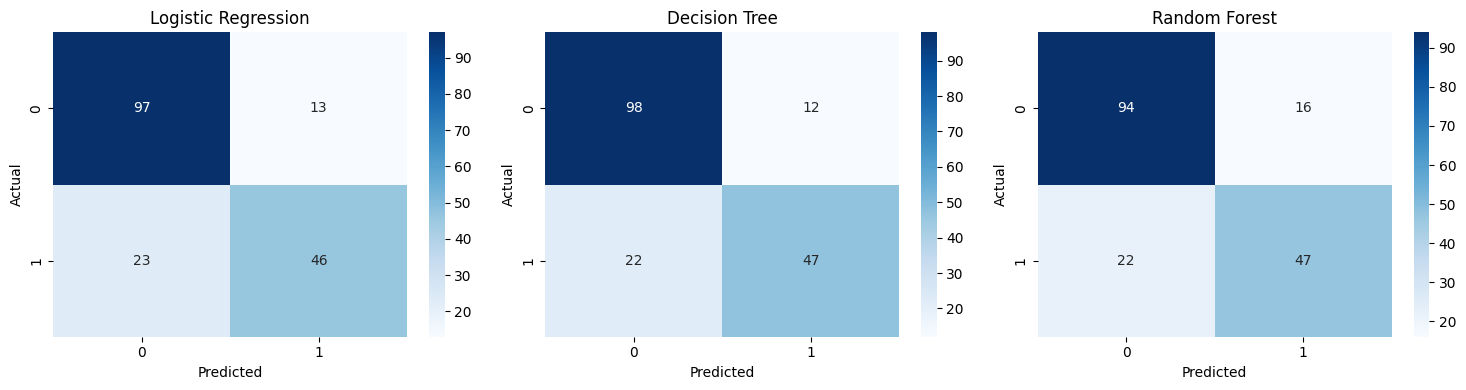

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

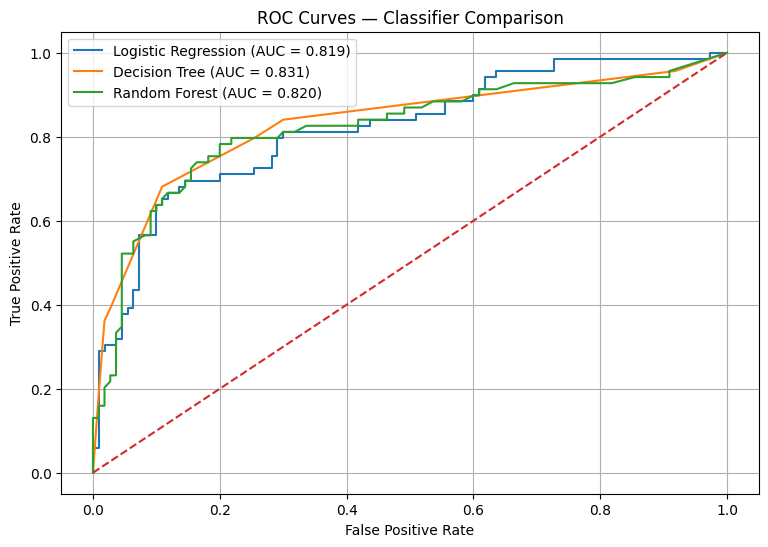

In [52]:
plt.figure(figsize=(9, 6))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
print("Logistic:", type(logistic_pipeline))
print("Decision Tree:", type(decision_tree_pipeline))
print("Random Forest:", type(random_forest_pipeline))

Logistic: <class 'sklearn.pipeline.Pipeline'>
Decision Tree: <class 'sklearn.pipeline.Pipeline'>
Random Forest: <class 'sklearn.pipeline.Pipeline'>


In [54]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

classification_results = pd.DataFrame(results)

display(
    classification_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.799,0.780,0.667,0.719,0.819
1,Decision Tree,0.810,0.797,0.681,0.734,0.831
2,Random Forest,0.788,0.746,0.681,0.712,0.820


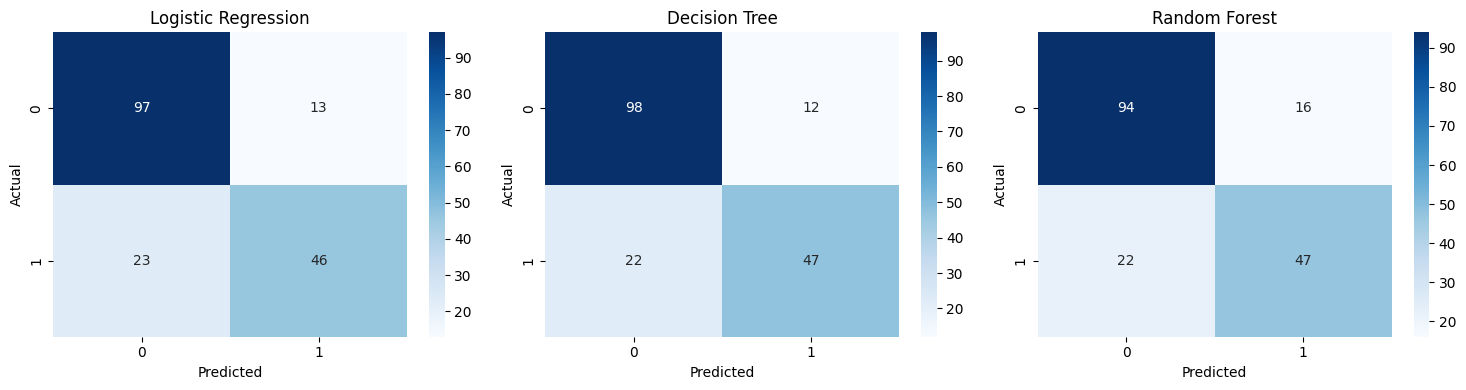

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

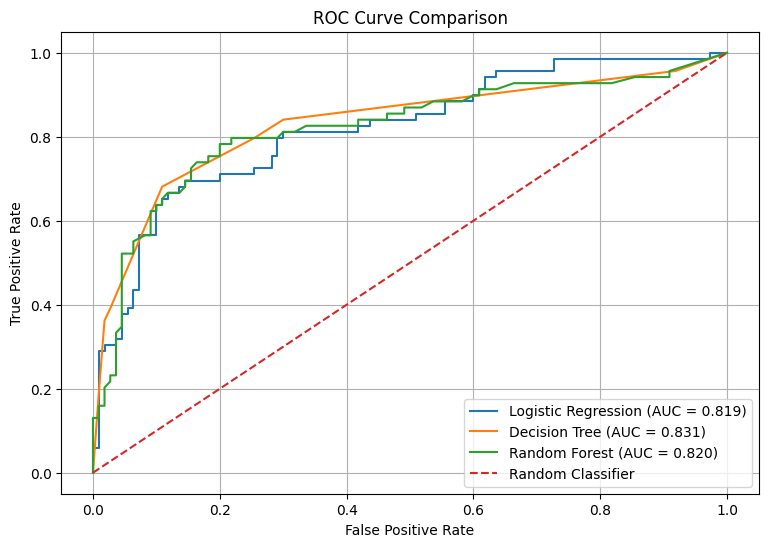

In [56]:
plt.figure(figsize=(9, 6))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

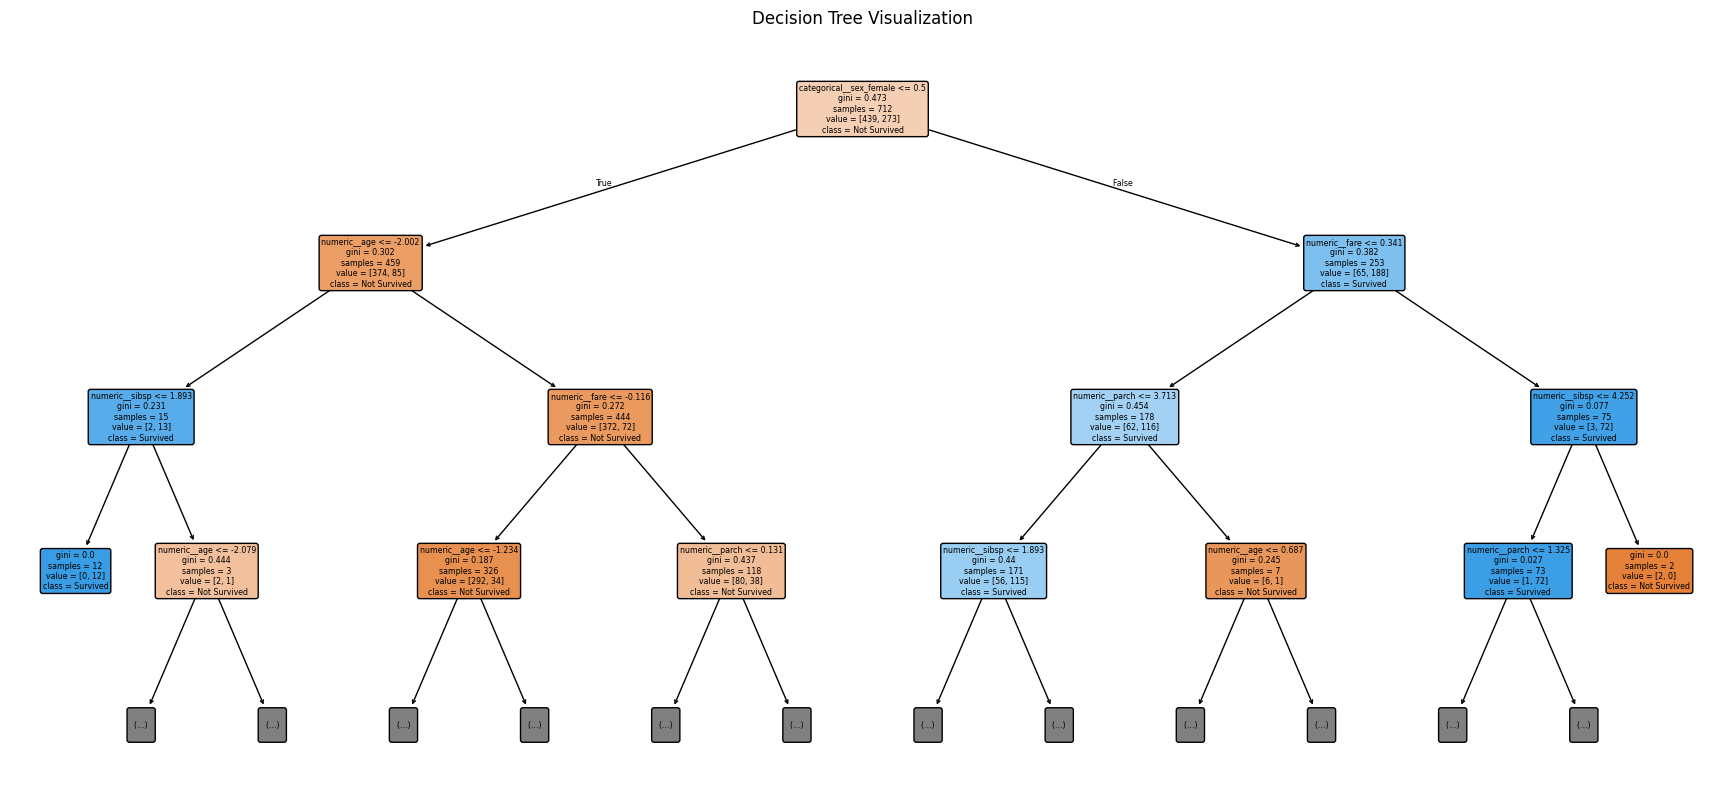

In [57]:
from sklearn.tree import plot_tree

# Get fitted preprocessing and tree model
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
tree_model = decision_tree_pipeline.named_steps["model"]

# Transform training data using the already-fitted preprocessor
X_train_transformed = tree_preprocessor.transform(X_train)

# Get feature names after one-hot encoding
feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

In [58]:
print("Overall class balance:")
display(
    y.value_counts()
      .rename(index={0: "Not Survived", 1: "Survived"})
      .to_frame("count")
)

print("\nClass percentages:")
display(
    (y.value_counts(normalize=True) * 100)
      .rename(index={0: "Not Survived", 1: "Survived"})
      .round(2)
      .to_frame("percentage")
)

Overall class balance:


,count
survived,
Not Survived,549
Survived,342



Class percentages:


,percentage
survived,
Not Survived,61.62
Survived,38.38


In [59]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [60]:
# 1. Baseline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)


# 2. Class-weight balanced
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)


# 3. SMOTE
# First preprocess training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

print("All three imbalance strategies trained successfully!")

All three imbalance strategies trained successfully!


In [61]:
imbalance_results = []

# Baseline and balanced
for name, model in [
    ("Baseline", baseline_model),
    ("Class Weight Balanced", balanced_model)
]:
    pred = model.predict(X_test)

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })


# SMOTE
smote_pred = smote_model.predict(X_test_processed)

imbalance_results.append({
    "Strategy": "SMOTE",
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred)
})

imbalance_comparison = pd.DataFrame(imbalance_results)

display(
    imbalance_comparison.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)

,Strategy,Precision,Recall,F1
0,Baseline,0.746,0.681,0.712
1,Class Weight Balanced,0.742,0.667,0.702
2,SMOTE,0.690,0.710,0.700


The baseline Random Forest achieved the highest precision (0.746) and F1 score (0.712), while SMOTE achieved the highest recall (0.710). Class weighting did not improve the baseline results, producing a lower F1 score of 0.702. Since the baseline achieved the best overall F1 score and precision, it is the strongest strategy for balanced overall performance, while SMOTE may be preferred when identifying as many survivors as possible is more important than precision.

In [62]:
from sklearn.model_selection import GridSearchCV

rf_for_grid = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

rf_pipeline_for_grid = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_for_grid)
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 50}

Best cross-validation F1:
0.7503737799064902


In [63]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["model"]

print("OOB Score:", best_rf_model.oob_score_)

OOB Score: 0.8089887640449438


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict fare
reg_df = df.copy()

X_reg = reg_df.drop("fare", axis=1)
y_reg = reg_df["fare"]

# Remove target-related/boolean derived columns
X_reg = X_reg.drop(
    columns=["survived", "adult_male", "alone"],
    errors="ignore"
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

numeric_reg = X_reg_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_reg = X_reg_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", numeric_reg)
print("Categorical features:", categorical_reg)

Numeric features: ['pclass', 'age', 'sibsp', 'parch']
Categorical features: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


In [65]:
reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_reg
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_reg
    )
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("Regression model trained successfully!")

Regression model trained successfully!


In [66]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)

# Number of predictors after one-hot encoding
X_reg_test_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print(f"Adjusted R²: {adjusted_r2:.3f}")

MAE: 17.261
RMSE: 28.999
R²: 0.457
Adjusted R²: 0.359


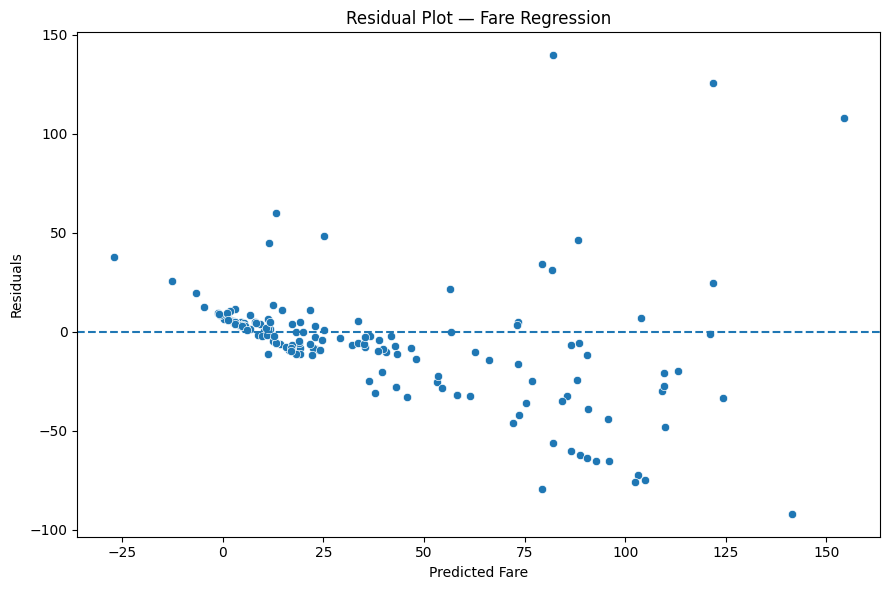

In [67]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Regression")

plt.tight_layout()
plt.show()

Residual Analysis: The residuals show a

non-constant spread as the predicted fare increases. The points are tightly clustered for lower predicted fares but become much more dispersed at higher predicted fares, forming a funnel-like pattern. Therefore, the residual plot provides evidence of heteroscedasticity, indicating that the constant-variance assumption of linear regression is violated. A non-linear transformation or a more suitable non-linear regression model could be considered for improved modeling.

In [68]:
# Classification results
final_classification = classification_results.copy()

# Add regression metrics as separate columns
final_classification["MAE"] = mae
final_classification["RMSE"] = rmse
final_classification["R2"] = r2
final_classification["Adjusted_R2"] = adjusted_r2

display(
    final_classification.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}",
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.3f}",
        "Adjusted_R2": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R2,Adjusted_R2
0,Logistic Regression,0.799,0.780,0.667,0.719,0.819,17.261,28.999,0.457,0.359
1,Decision Tree,0.810,0.797,0.681,0.734,0.831,17.261,28.999,0.457,0.359
2,Random Forest,0.788,0.746,0.681,0.712,0.820,17.261,28.999,0.457,0.359


Classification metrics: Accuracy, Precision, Recall, F1 and AUC are used to compare the three classification models.

Regression metrics: MAE, RMSE, R² and Adjusted R² describe the separate fare-prediction regression task. These two groups of metrics are not directly comparable because they measure different types of prediction performance.

Final Recommendation: The Decision Tree is the recommended classifier because it achieved the highest accuracy (0.810), precision (0.797), F1 score (0.734), and AUC (0.831) among the three models. Its recall of 0.681 is equal to the Random Forest and slightly higher than Logistic Regression (0.667). Logistic Regression provides competitive performance but has lower accuracy and AUC, while Random Forest unexpectedly performs worse than the Decision Tree on this split. Therefore, based on the evaluated metrics, the Decision Tree provides the strongest overall classification performance for this dataset.

In [69]:
final_comparison = classification_results.copy()

# Classification metrics only
classification_display = final_comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

display(classification_display)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.798883,0.779661,0.666667,0.718750,0.819368
1,Decision Tree,0.810056,0.796610,0.681159,0.734375,0.830896
2,Random Forest,0.787709,0.746032,0.681159,0.712121,0.820487


In [70]:
regression_display = pd.DataFrame({
    "Regression Model": ["Multivariate Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted_R2": [adjusted_r2]
})

display(regression_display)

,Regression Model,MAE,RMSE,R2,Adjusted_R2
0,Multivariate Linear Regression,17.261172,28.999214,0.456548,0.359374


In [71]:
import joblib
import os

pipeline_path = "/content/drive/MyDrive/Colab Notebooks/analytics/best_titanic_pipeline.joblib"

joblib.dump(
    decision_tree_pipeline,
    pipeline_path
)

print("Pipeline saved successfully!")
print(pipeline_path)

Pipeline saved successfully!
/content/drive/MyDrive/Colab Notebooks/analytics/best_titanic_pipeline.joblib


In [72]:
loaded_pipeline = joblib.load(pipeline_path)

print("Pipeline loaded successfully!")
print(loaded_pipeline)

Pipeline loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                

In [73]:
raw_sample = X_test.iloc[[0]].copy()

prediction = loaded_pipeline.predict(raw_sample)

print("Raw input:")
display(raw_sample)

print("Predicted survival:", prediction[0])
print("Actual survival:", y_test.iloc[0])

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
565,3,male,24.0,2,0,24.15,S,Third,man,True,NaN,Southampton,no,False


Predicted survival: 0
Actual survival: 0


In [74]:
print("Pipeline type:", type(loaded_pipeline))
print("Can predict raw data:", hasattr(loaded_pipeline, "predict"))

Pipeline type: <class 'sklearn.pipeline.Pipeline'>
Can predict raw data: True


In [75]:
readme_path = "/content/drive/MyDrive/Colab Notebooks/analytics/README.md"

readme_content = """
# Analytics Module — Titanic Dataset

## 1. Overview

This module implements an analyst-to-data-scientist workflow using the Titanic dataset.

The workflow covers:
- Data loading and profiling
- Missing-value handling
- Exploratory data analysis
- Outlier analysis
- Correlation analysis
- Data visualization
- Classification modeling
- Class imbalance comparison
- Hyperparameter tuning
- Fare regression
- Model persistence

## 2. Dataset

The Titanic dataset was loaded using Seaborn's built-in loader during the EDA stage.

An offline fallback file named `titanic.csv` was created using:

`df.to_csv("titanic.csv", index=False)`

The modeling notebook reads this committed CSV instead of independently loading the dataset again.

## 3. Missing-Value Handling

Missing-value percentages were calculated immediately after loading the dataset.

The following threshold rule was used:

- Less than 5% missing: affected rows were dropped.
- 5% to 30% missing: values were imputed.
- More than 30% missing: the column was dropped when imputation was considered unreliable.

The exact measured percentages and the corresponding decisions are documented in the EDA notebook.

## 4. Exploratory Data Analysis

Age and fare were analyzed using histograms and box plots.

The IQR rule was used to identify outliers:

Lower bound = Q1 - 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

Fare mean, median, and mode were calculated to assess its skewness.

Survival rates were analyzed by:
- Sex
- Passenger class
- Sex and passenger class together

A correlation matrix was created using exactly:
- survived
- pclass
- age
- sibsp
- parch
- fare

The boolean-derived columns `adult_male` and `alone` were excluded.

## 5. Standardization

Age and fare were standardized using z-score standardization.

The transformed variables were verified to have approximately:
- Mean = 0
- Standard deviation = 1

This was an EDA sanity check only and was not used as the modeling pipeline's preprocessing.

## 6. Classification

A stratified 80/20 train-test split was used.

Features included:
- age
- sibsp
- parch
- fare
- sex
- embarked

Preprocessing was implemented using a scikit-learn Pipeline and ColumnTransformer.

Numeric features used median imputation and StandardScaler.

Categorical features used most-frequent imputation and OneHotEncoder.

Three classifiers were trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

## 7. Classification Results

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.799 | 0.780 | 0.667 | 0.719 | 0.819 |
| Decision Tree | 0.810 | 0.797 | 0.681 | 0.734 | 0.831 |
| Random Forest | 0.788 | 0.746 | 0.681 | 0.712 | 0.820 |

The Decision Tree achieved the strongest overall classification performance.

## 8. Class Imbalance

| Strategy | Precision | Recall | F1 |
|---|---:|---:|---:|
| Baseline | 0.746 | 0.681 | 0.712 |
| Class Weight Balanced | 0.742 | 0.667 | 0.702 |
| SMOTE | 0.690 | 0.710 | 0.700 |

The baseline achieved the highest F1 score and precision. SMOTE achieved the highest recall, but its precision and F1 were lower than the baseline.

## 9. Hyperparameter Tuning

Random Forest hyperparameters were tuned using GridSearchCV for:
- n_estimators
- max_depth
- max_features

The Random Forest estimator was configured with `oob_score=True` so that an out-of-bag score could be reported.

The exact best parameters and OOB score are recorded in the modeling notebook output.

## 10. Regression

A multivariate Linear Regression model was used to predict fare.

Results:

| Metric | Value |
|---|---:|
| MAE | 17.261 |
| RMSE | 28.999 |
| R² | 0.457 |
| Adjusted R² | 0.359 |

The residual plot showed a funnel-like increase in residual spread at higher predicted fare values, providing evidence of heteroscedasticity.

## 11. Final Recommendation

The Decision Tree is the recommended classifier because it achieved the highest accuracy (0.810), precision (0.797), F1 score (0.734), and AUC (0.831). Its recall of 0.681 was equal to the Random Forest and higher than Logistic Regression at 0.667. Therefore, based on the evaluated metrics, the Decision Tree provided the strongest overall classification performance on the test split.

## 12. Saved Model

The complete fitted Decision Tree pipeline was saved using `joblib.dump()`.

The saved artifact contains both preprocessing steps and the final estimator, allowing raw input data to be passed directly to the pipeline.

The saved pipeline was reloaded using `joblib.load()` and successfully produced predictions on raw test input.

## 13. Run Instructions

1. Open `01_eda.ipynb`.
2. Load and profile the Titanic dataset.
3. Save the offline fallback `titanic.csv`.
4. Complete cleaning and EDA.
5. Open `02_Modeling.ipynb`.
6. Read `titanic.csv`.
7. Run the preprocessing, classification, imbalance, tuning, and regression sections.
8. Generate and save the final pipeline artifact.

## 14. Files

- `01_eda.ipynb` — profiling, cleaning and EDA
- `02_Modeling.ipynb` — predictive modeling and regression
- `titanic.csv` — offline dataset fallback
- `best_titanic_pipeline.joblib` — complete fitted Decision Tree pipeline
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")
print(readme_path)

README.md created successfully!
/content/drive/MyDrive/Colab Notebooks/analytics/README.md
